### DATA CLEANING & EXPLORATION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import janitor
from plotnine import *

In [2]:
titanic = pd.read_csv('titanic_train.csv')

In [3]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic = titanic.clean_names()

In [5]:
titanic.shape

(891, 12)

In [6]:
titanic.isna().sum()

passengerid      0
survived         0
pclass           0
name             0
sex              0
age            177
sibsp            0
parch            0
ticket           0
fare             0
cabin          687
embarked         2
dtype: int64

In [7]:
# I'd drop the cabin column cause the missing values are too much, then replace missing ages with median

titanic = titanic.drop(['cabin'], axis =1)

In [8]:
titanic.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [9]:
titanic['age'] = titanic['age'].fillna(titanic['age'].median())

In [10]:
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])

In [11]:
titanic.isna().sum()

passengerid    0
survived       0
pclass         0
name           0
sex            0
age            0
sibsp          0
parch          0
ticket         0
fare           0
embarked       0
dtype: int64

In [12]:
titanic.shape

(891, 11)

In [13]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    str    
 4   sex          891 non-null    str    
 5   age          891 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    str    
 9   fare         891 non-null    float64
 10  embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 111.0 KB


In [14]:
titanic.duplicated().sum()

np.int64(0)

In [15]:
titanic.describe()

,passengerid,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


##### Interpretation

-The dataset contains records for 891 passengers aboard the Titanic.

-The average age of the passengers is approximately 29.4 years, after filling in the missing age values.

-The youngest passenger was about 0.42 years old (approximately 5 months), while the oldest was 80 years old.

-About 38.4% of the passengers survived (Survived mean = 0.3838), meaning roughly 3 out of every 10 passengers survived.

-The average fare paid was 32.20, but fares ranged from 0 to 512.33, indicating a very wide variation in ticket prices.

-Most passengers traveled in third class since the median (50%) and the 75th percentile for Pclass are both 3.

-Most passengers were traveling without siblings/spouses (SibSp median = 0) and without parents/children (Parch median = 0).

-The mean age (29.36 years) is slightly higher than the median age (28 years), suggesting that the age distribution is approximately symmetric with a slight positive (right) skew.    
                                                            

### EXPLORATORY DATA ANALYSIS(EDA)

In [16]:
# How many people survived?

titanic_survival=titanic['survived'].value_counts()
print(titanic_survival)

survived
0    549
1    342
Name: count, dtype: int64


In [17]:
titanic['survived_label'] = titanic['survived'].map({0 : 'Died', 1:'Lived'})

counts = titanic['survived_label'].value_counts().reset_index()

counts.columns = ('survived_label', 'count')

In [100]:
NAVY = '#154360'
GOLD = '#d68910'
LIGHT_BLUE = '#5dade2'
PALE_BLUE = '#d6eaf8'
GRAY_TEXT = '#333333'

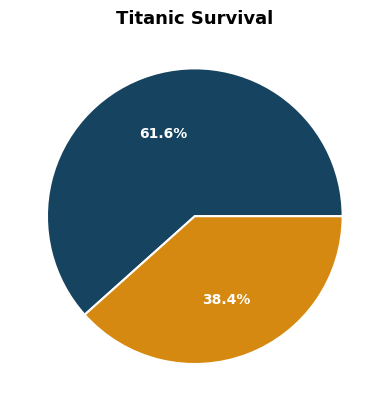

In [101]:
plt.pie(counts['count'], labels=counts['survived_label'], autopct='%1.1f%%',
         colors=[NAVY, GOLD], textprops={'color':'white', 'fontweight':'bold'},
         wedgeprops={'edgecolor':'white', 'linewidth':1.5})
plt.title('Titanic Survival', fontsize=13, fontweight='bold')
plt.show()

##### Interpretation

-The dataset shows that the majority of passengers (61.6%) did not survive, whereas 38.4% survived. This indicates that fatalities exceeded survivals among the passengers on board.

In [19]:
# What's the survival rate by gender?

gender_survival = titanic.groupby('sex')['survived'].agg('mean')
print(gender_survival)

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


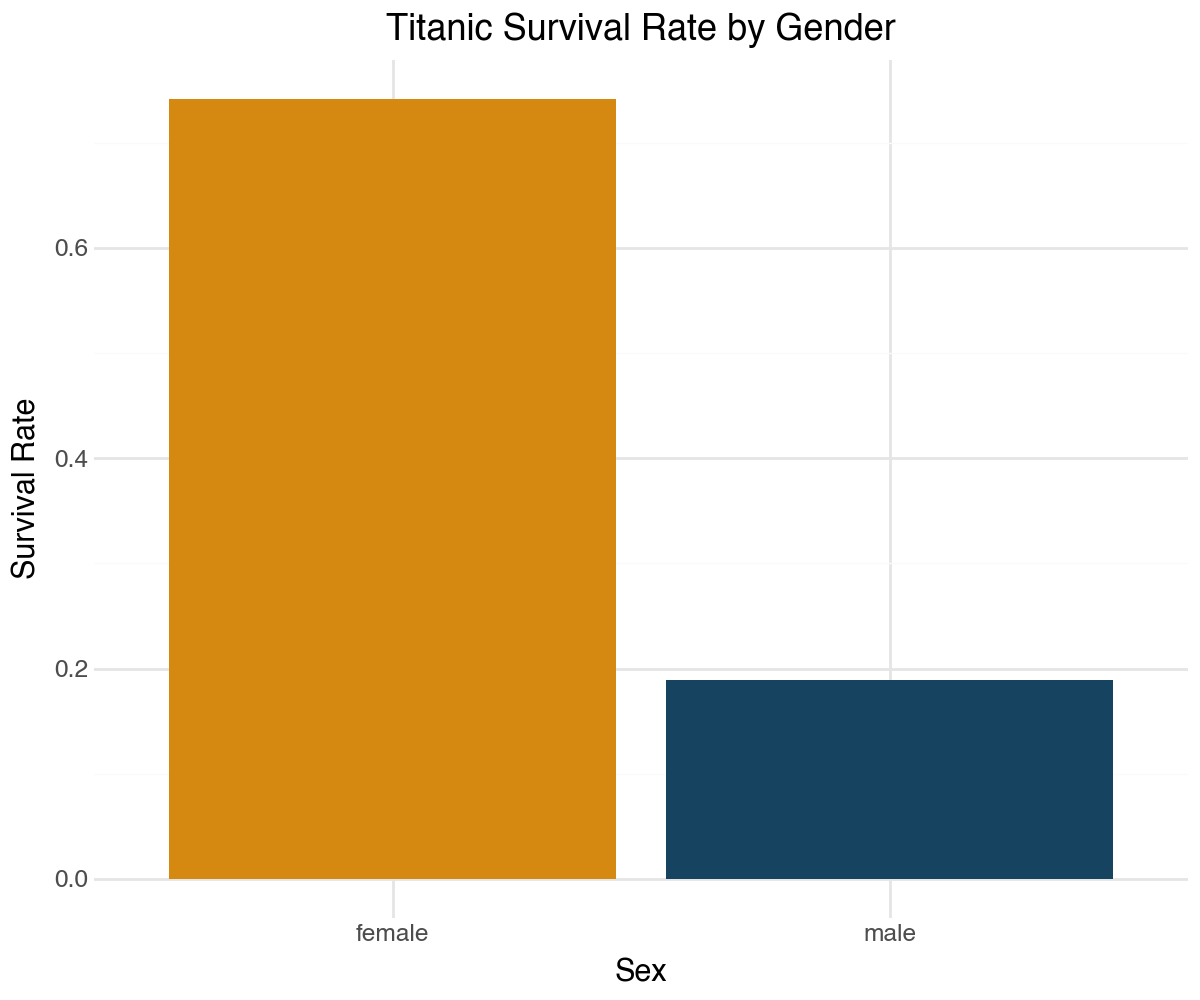

In [102]:
(
    ggplot(titanic, aes(x='sex', y='survived', fill='sex'))
    + geom_bar(stat='summary', fun_y=lambda x: x.mean())
    + scale_fill_manual(values={'female': GOLD, 'male': NAVY})
    + labs(x='Sex', y='Survival Rate', title='Titanic Survival Rate by Gender')
    + theme_minimal()
    + theme(figure_size=(6,5), legend_position='none',
            plot_title=element_text(size=13, weight='bold'))
)

##### Interpretation

Female passengers had a much higher survival rate (74.2%) than male passengers (18.9%). This suggests that women were considerably more likely to survive than men on the Titanic.

In [21]:
# Which passenger class had the highest survival rate?
# Which class had the most passengers?

titanic.groupby('pclass')['survived'].agg(['mean','sum','count'])

,mean,sum,count
pclass,,,
1,0.629630,136,216
2,0.472826,87,184
3,0.242363,119,491


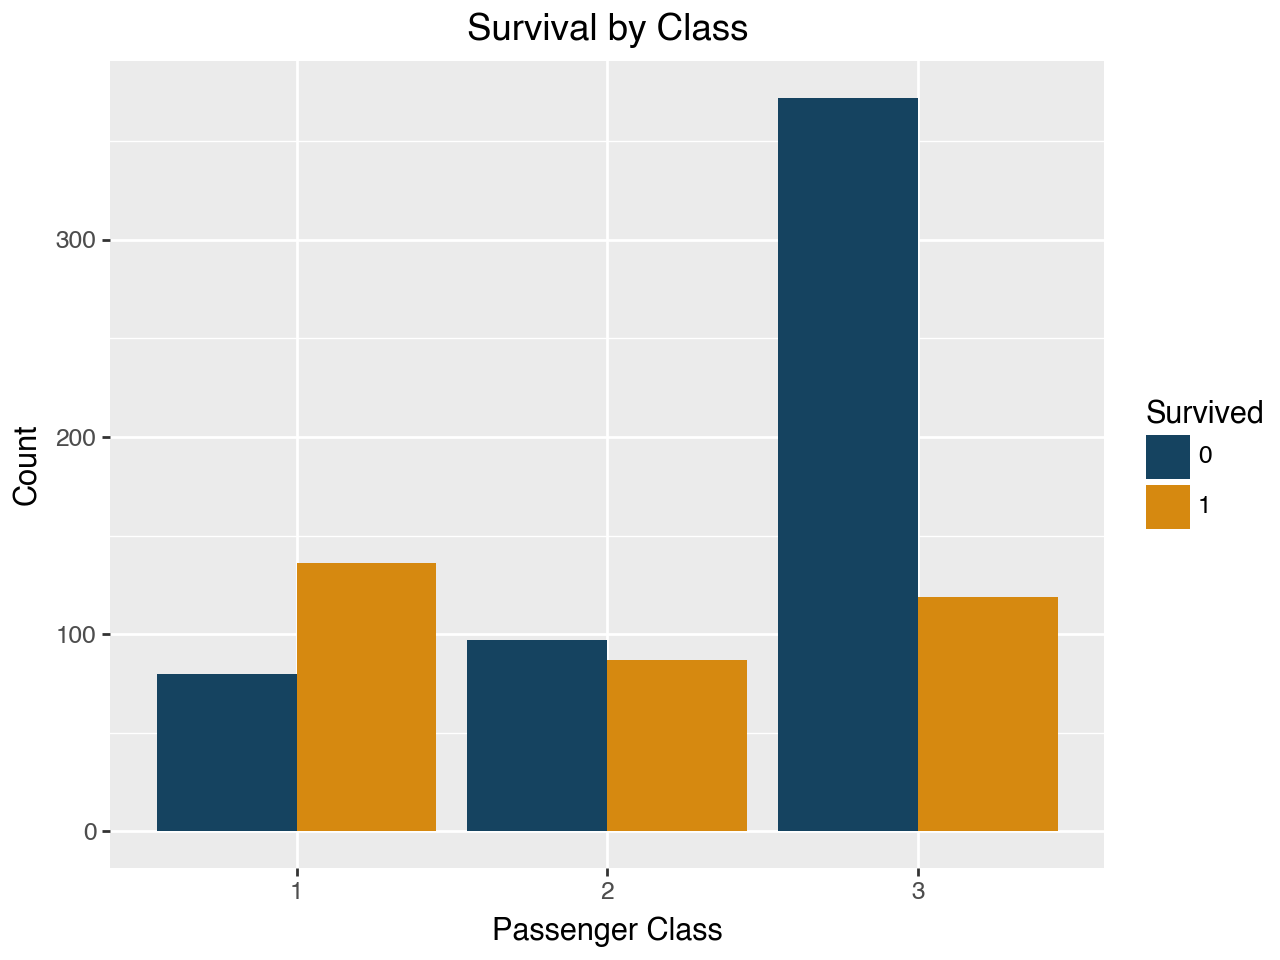

In [107]:
from plotnine import ggplot, aes, geom_bar, labs

(
    ggplot(titanic, aes(x='factor(pclass)', fill='factor(survived)'))
    + geom_bar(position='dodge')
    + scale_fill_manual(values={1: GOLD, 0: NAVY})
    + labs(x='Passenger Class', y='Count', fill='Survived', title='Survival by Class')
)

##### Interpretation
The stacked bar chart shows both the number of passengers and their survival outcomes across the three passenger classes. 
Class 1 had 216 passengers total, the smallest group, but the best odds of survival - about 136 (63%) survived while roughly 80 died. 
Class 2 had 184 passengers with a near-even split, about 87 (47%) surviving and 97 dying. 
Class 3, by contrast, had by far the largest group at 491 passengers, more than classes 1 and 2 combined, yet the worst survival rate, with only about 119 (24%) surviving and 372 dying. 
Overall, the chart reveals a clear class gradient: survival odds decreased steadily from 1st to 3rd class, and since 3rd class made up the majority of passengers on board, most people on the Titanic belonged to the group least likely to survive.

<Axes: ylabel='Frequency'>

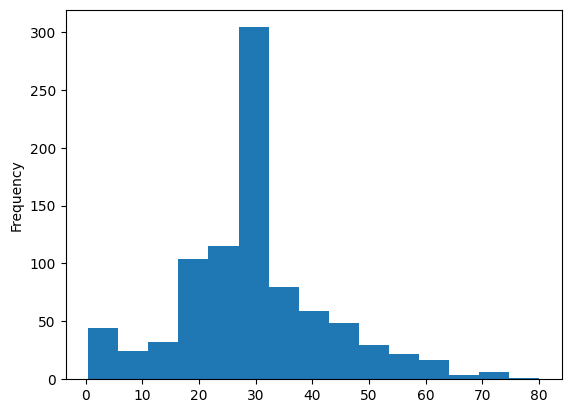

In [23]:
# What is the age distribution?

titanic['age'].plot(kind='hist', bins=15)

In [24]:
titanic['age'].describe()

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: age, dtype: float64

##### Interpretation
This shows the min age was ~5 months and the max was 80 years. Most passengers were in their 20s-30s (25th-75th percentile: 22-35). Note the tall spike at age 28 is inflated by the median-fill used for missing values, not a natural clustering of real passengers.

In [25]:
# Were younger people more likely to survive?

titanic.groupby('survived')['age'].mean()

survived
0    30.028233
1    28.291433
Name: age, dtype: float64

##### Interpretation
The average age of passengers who survived was 28.29 years, compared to 30.03 years for those who did not survive. This indicates that 
survivors were slightly younger on average. However, the difference is relatively small (approximately 1.7 years), so additional analysis 
is needed to determine whether age had a meaningful impact on survival

In [26]:
# What's the fare distribution?

titanic['fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64

<Axes: >

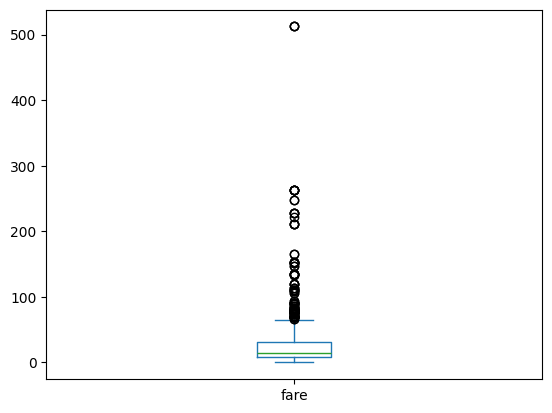

In [27]:
titanic['fare'].plot(kind ='box',)

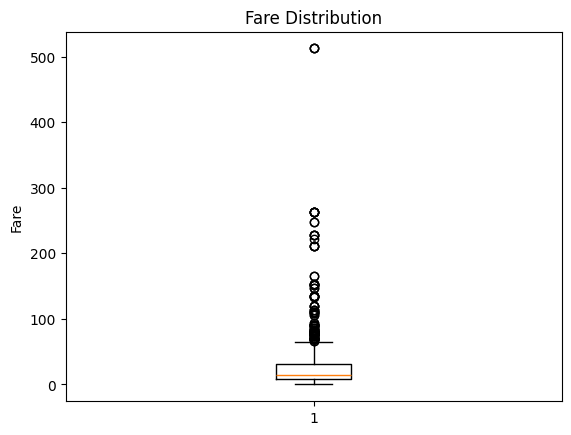

In [28]:
import matplotlib.pyplot as plt
plt.boxplot(titanic['fare'])
plt.title('Fare Distribution')
plt.ylabel('Fare')
plt.show()

##### Interpretation
Most passengers paid low fares, the box (middle 50% of passengers) sits close to the bottom, roughly between 8 and 31 pounds, with a median around 14.50. 

The whiskers stretch a bit further, up to about 65, covering the "normal" range of fares. Above that, every dot seen is an outlier, a passenger who paid noticeably more than most others, and they trail all the way up to one extreme case near $512, far above everyone else. 
Overall: fares are cheap for the majority, with a small number of passengers paying dramatically more, pulling the distribution into a long right-hand tail.

In [29]:
# Did richer passengers survive more?

titanic.groupby('survived')['fare'].mean()

survived
0    22.117887
1    48.395408
Name: fare, dtype: float64

In [30]:
# splitted the fares into bins 


titanic['fareband'] = pd.qcut(titanic['fare'], 4)
titanic.groupby('fareband')['survived'].mean()

fareband
(-0.001, 7.91]     0.197309
(7.91, 14.454]     0.303571
(14.454, 31.0]     0.454955
(31.0, 512.329]    0.581081
Name: survived, dtype: float64

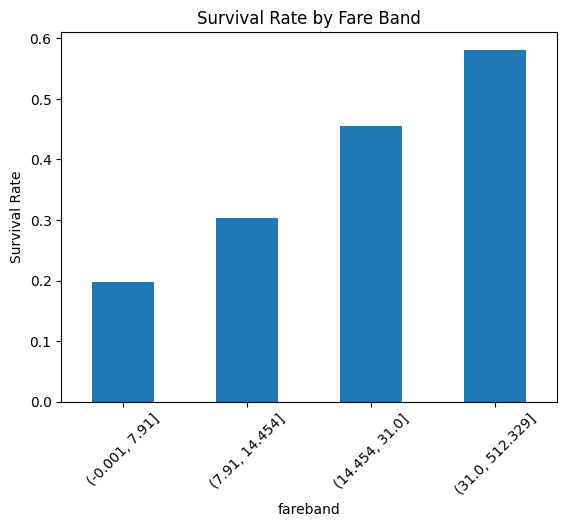

In [31]:
rates = titanic.groupby('fareband')['survived'].mean()

rates.plot(kind='bar')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Fare Band')
plt.xticks(rotation=45)
plt.show()

##### Interpretation 
The fare-band analysis confirms that wealthier passengers had a clear survival advantage aboard the Titanic. Splitting passengers into four 
equal-sized groups by fare paid, survival rate rose steadily from about 20% in the cheapest quarter (fares under 8) to roughly 30% in the 
second quarter, 44% in the third, and 59% in the priciest quarter (fares above 31 pounds) — nearly tripling from the lowest to the highest fare 
band. Because this increase is gradual across all four bands rather than driven by a handful of outliers, it represents a genuine, 
broad-based pattern rather than a statistical fluke. This finding closely mirrors the earlier survival-by-class results (1st class 63%, 
2nd class 47%, 3rd class 24%), which makes sense given how tightly Fare and Pclass are linked — Fare essentially serves as a finer-grained 
proxy for the same socioeconomic advantage that Pclass captures, reinforcing rather than contradicting that earlier finding.

In [32]:
# Which port had the most passengers?

port_count = titanic['embarked'].value_counts()
print(port_count)

embarked
S    646
C    168
Q     77
Name: count, dtype: int64


##### Interpretation

Most passengers embarked from Southampton (646), making it the busiest embarkation port. Cherbourg was the second most common embarkation point with 168 passengers, while Queenstown had the fewest passengers (77). This imbalance should be considered when comparing survival rates across embarkation ports, as the sample sizes differs substantially.

In [33]:
# Which port had the highest survival rate?

titanic.groupby('embarked')['survived'].mean()


embarked
C    0.553571
Q    0.389610
S    0.339009
Name: survived, dtype: float64

##### Interpretation
Interpretation: Passengers embarking from Cherbourg (55.4%) had the highest survival rate, while those from Southampton (33.9%) had the 
lowest. This suggests that survival rates varied by embarkation port. However, this difference may be influenced by other factors, such as 
passenger class, since embarkation port is likely associated with the socioeconomic status of passengers.

In [34]:
pd.crosstab(titanic['embarked'], titanic['pclass'], normalize='index') * 100

pclass,1,2,3
embarked,,,
C,50.595238,10.119048,39.285714
Q,2.597403,3.896104,93.506494
S,19.969040,25.386997,54.643963


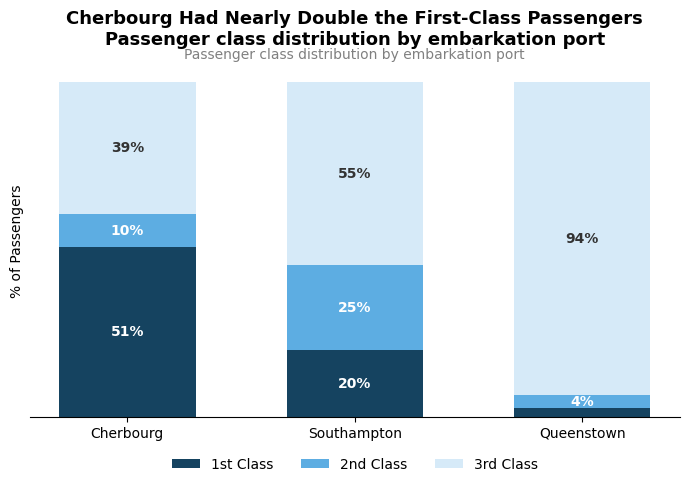

In [106]:


import matplotlib.pyplot as plt
import pandas as pd

port_class = pd.crosstab(titanic['embarked'], titanic['pclass'], normalize='index') * 100
port_class.columns = ['1st Class', '2nd Class', '3rd Class']

# sort so Cherbourg (highest 1st class %) leads
port_class = port_class.sort_values('1st Class', ascending=False)
port_class.index = port_class.index.map({'C':'Cherbourg', 'Q':'Queenstown', 'S':'Southampton'})

colors = ['#154360', '#5dade2', '#d6eaf8']  # dark to light blue
fig, ax = plt.subplots(figsize=(7,5))

bottom = pd.Series([0]*len(port_class), index=port_class.index)
for col, color in zip(port_class.columns, colors):
    ax.bar(port_class.index, port_class[col], bottom=bottom, label=col, color=color, width=0.6)
    for i, (idx, val) in enumerate(port_class[col].items()):
        if val > 3:  # skip tiny labels that would overlap
            ax.text(i, bottom[idx] + val/2, f'{val:.0f}%', ha='center', va='center',
                     color='white' if color != '#d6eaf8' else '#333', fontweight='bold', fontsize=10)
    bottom += port_class[col]

ax.set_ylabel('% of Passengers')
ax.set_title('Cherbourg Had Nearly Double the First-Class Passengers\n' +
              'Passenger class distribution by embarkation port',
              fontsize=13, fontweight='bold', pad=15)

ax.text(0.5, 1.02, 'Passenger class distribution by embarkation port', transform=ax.transAxes,
        ha='center', fontsize=10, color='gray')
ax.spines[['top','right','left']].set_visible(False)
ax.yaxis.grid(False)
ax.set_yticks([])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)

plt.tight_layout()
plt.show()

##### Interpretation

The passenger class distribution varied considerably across embarkation ports. More than half (50.6%) of passengers who 
embarked at Cherbourg traveled in first class, compared with only 20.0% of passengers from Southampton. Since first-class passengers had 
higher survival rates, this helps explain why Cherbourg recorded the highest survival rate among the three embarkation ports.

### FEATURE ENGINEERING

In [35]:
# Did passengers traveling alone survive more?

titanic['family_size'] = titanic['sibsp'] + titanic['parch']
titanic['isalone'] = (titanic['family_size'] == 0).astype(int)


In [36]:
titanic.groupby('isalone')['survived'].mean()
#alone is 1, not alone is 0

isalone
0    0.505650
1    0.303538
Name: survived, dtype: float64

##### Interpretation

Passengers traveling with family (IsAlone = 0) had a survival rate of about 50.6%, while those traveling alone (IsAlone = 1) survived at a 
much lower rate of about 30.4%. That's roughly a 20 percentage point gap,being with family roughly doubled your odds of survival compared 
to traveling solo.
This is actually somewhat surprising at first glance (you might expect solo travelers to move faster/more freely during evacuation), but it 
likely reflects a few underlying factors: family groups may have helped each other reach lifeboats, "women and children first" protocols 
would have prioritized whole family units, and solo travelers may have skewed toward single young men (often 3rd class)the demographic 
we already know had the worst outcomes overall.

In [37]:
titanic.groupby('isalone')['sex'].value_counts(normalize=True)

isalone  sex   
0        female    0.531073
         male      0.468927
1        male      0.765363
         female    0.234637
Name: proportion, dtype: float64

##### Interpretation

Solo travelers on the Titanic were overwhelmingly men, while those traveling with family were roughly split evenly between men and women. This matters because it tells you IsAlone and Sex aren't independent of each other, they're correlated (most "alone" passengers are men). That's exactly why, when we looked at survival by IsAlone alone, the "alone" group appeared to survive much worse, a big part of that was really the male survival disadvantage showing up again, since the alone group was mostly male. It's the reason we then split by Sex and IsAlone together to see the real, untangled effect.

In [38]:
# Did large families survive less?

rates = titanic.groupby('family_size')['survived'].mean().reset_index()
print(rates)

   family_size  survived
0            0  0.303538
1            1  0.552795
2            2  0.578431
3            3  0.724138
4            4  0.200000
5            5  0.136364
6            6  0.333333
7            7  0.000000
8           10  0.000000


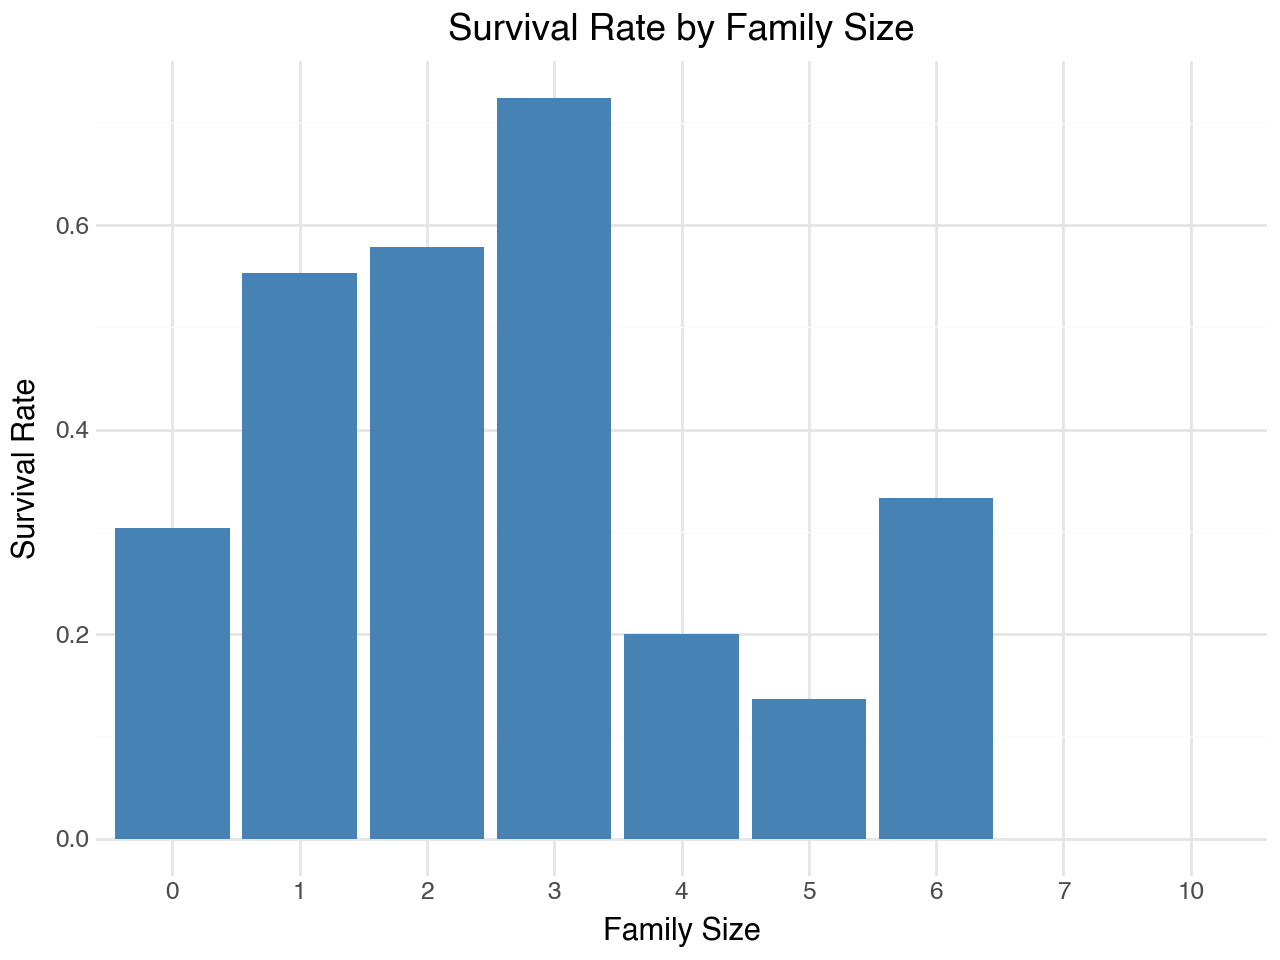

In [39]:
(
    ggplot(rates, aes(x='factor(family_size)', y='survived'))
            +geom_bar(stat ='identity', fill='steelblue')
            +theme_minimal()  
            +labs(x='Family Size',
                  y='Survival Rate',
                  title='Survival Rate by Family Size')
           
)

##### Interpretation

Survival rate by family size does not follow a simple linear pattern, but rather rises and then falls sharply. Passengers traveling 
completely alone (family size 0) had a survival rate of about 30%, but this rose notably for small families — reaching roughly 55% at 
family size 1, 58% at family size 2, and peaking at about 72% for family size 3, suggesting that having a few family members aboard improved survival odds, likely due to mutual assistance during evacuation. Beyond that peak, however, 
survival collapsed for larger families: family sizes 4 and 5 dropped to around 20% and 14% respectively, before ticking back up slightly 
to 33% at family size 6. Family sizes 7 and 10 show a survival rate of exactly 0%, but these bars are barely visible on the chart because 
they represent extremely small groups (only 6 and 7 passengers respectively), so this result should be treated cautiously rather than as a 
reliable trend. 
Overall, the pattern suggests a "sweet spot" around small family sizes (1-3) for the best survival odds, with both solo 
travelers and large family groups faring noticeably worse — a relationship that is non-linear and therefore would not show up clearly in a 
simple correlation coefficient, even though the underlying pattern is real.

### HYPOTHESIS TESTING

##### 1 Sex vs. Survived - Chi-square test(since both variables are categorical)

Null Hypothesis(H₀): Sex and Survived are independent. There's no real relationship between them

Alternative Hypothesis(H₁): Sex and Survived are not independent and there's real relationship between them


In [44]:
# Create a contigency table

from scipy.stats import chi2_contingency

contingency = pd.crosstab(titanic['sex'], titanic['survived'])
print(contingency)

survived    0    1
sex               
female     81  233
male      468  109


In [45]:
# Run the test

chi2,p,dof,expected = chi2_contingency(contingency)
print(f"Chi2 statistic: {chi2:.3f}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")
print(f"expected: {expected}")

Chi2 statistic: 260.717
p-value: 1.1973570627755645e-58
Degrees of freedom: 1
expected: [[193.47474747 120.52525253]
 [355.52525253 221.47474747]]


##### Interpretation
The test produced a Chi-square statistic of 260.717 with 1 degree of freedom and a p-value of approximately 1.2 × 10⁻⁵⁸, which is far below 
the significance level of 0.05. Therefore, we reject the null hypothesis and conclude that there is a statistically significant association 
between passenger sex and survival. This indicates that survival was not independent of sex, with female passengers having a much higher 
survival rate than male passengers.

##### Conclusion:

There is sufficient statistical evidence to conclude that passenger sex was significantly associated with survival on the Titanic.

##### 2 Pclass vs. Survived - Chi-square test

Null Hypothesis(H₀): PClass and Survived are independent. There's no real relationship between them

Alternative Hypothesis(H₁): PClass and Survived are not independent and there is real relationship between them


In [48]:
# Create contigency table

contingency2 =pd.crosstab(titanic['pclass'], titanic['survived'])
print(contingency2)

survived    0    1
pclass            
1          80  136
2          97   87
3         372  119


In [50]:
chi2_pclass,p_pclass,dof_pclass,expected_pclass = chi2_contingency(contingency2)

print(f"Chi2 statistic: {chi2_pclass:.3f}")
print(f"p-value: {p_pclass}")
print(f"Degrees of freedom: {dof_pclass}")
print(f"expected: {expected_pclass}")

Chi2 statistic: 102.889
p-value: 4.549251711298793e-23
Degrees of freedom: 2
expected: [[133.09090909  82.90909091]
 [113.37373737  70.62626263]
 [302.53535354 188.46464646]]


##### Interpretation
A Chi-Square Test of Independence showed a statistically significant association between passenger class and survival (χ² = 102.889, p < 0.05).
Therefore, we reject the null hypothesis and conclude that survival was significantly associated with passenger class. This supports the 
earlier EDA findings, which showed that first-class passengers had the highest survival rates, while third-class passengers had the lowest.


##### Conclusion:

There is sufficient statistical evidence to conclude that passenger PClass was significantly associated with survival on the Titanic.

##### 3 IsAlone vs. Survived - Chi-square test

Null Hypothesis(H₀): IsAlone and Survived are independent. There's no real relationship between them

Alternative Hypothesis(H₁): PClass and Survived are not independent and there's real relationship between them


In [54]:
contingency3 = pd.crosstab(titanic['isalone'],titanic['survived'])
print(contingency3)

survived    0    1
isalone           
0         175  179
1         374  163


In [55]:
chi2_isalone,p_isalone,dof_isalone,expected_isalone = chi2_contingency(contingency3)

print(f"Chi2 statistic: {chi2_isalone:.3f}")
print(f"p-value: {p_isalone}")
print(f"Degrees of freedom: {dof_isalone}")
print(f"expected: {expected_isalone}")

Chi2 statistic: 36.001
p-value: 1.9726543846517113e-09
Degrees of freedom: 1
expected: [[218.12121212 135.87878788]
 [330.87878788 206.12121212]]


##### Interpretation
A Chi-Square Test of Independence was conducted to examine the relationship between IsAlone and Survival. The test yielded a Chi-square 
statistic of 36.001 with 1 degree of freedom and a p-value of 1.97 × 10⁻⁹, which is well below the significance level of 0.05. Therefore, 
we reject the null hypothesis and conclude that there is a statistically significant association between whether a passenger was travelling 
alone and their survival.

##### Conclusion:

There is sufficient statistical evidence to conclude that the IsAlone feature was significantly associated with survival on the Titanic.
This finding supports the earlier exploratory data analysis, which suggested that passengers travelling with family members were more likely to survive than those travelling alone.

##### 4 Fare vs Survived Mann-Whitney U test(since fare is continuous & survived is categorical) 

H₀ (null): The distribution of Fare is the same for passengers who survived and those who died - there's no real difference between the two groups.

H₁ (alternative): The distribution of Fare differs between passengers who survived and those who died.

In [60]:
from scipy.stats import mannwhitneyu

fare_survived = titanic[titanic['survived']==1]['fare']
fare_died = titanic[titanic['survived']==0]['fare']
stat, p = mannwhitneyu(fare_survived, fare_died)
print(f"Statistic: {stat}, p-value: {p}")

Statistic: 129951.5, p-value: 4.553477179250237e-22


##### Conclusion
Since p < 0.05, we reject the null hypothesis. There is a statistically significant difference in Fare between survivors and non-survivors. This supports the earlier EDA finding that passengers who paid higher fares had better survival odds.

##### 5 Age vs Survived Mann-Whitney U test(since fare is continuous & survived is categorical) 
H₀(null): The distribution of Age is the same for survivors and non-survivors.

H₁(alternative): The distribution of Age differs between survivors and non-survivors.

In [61]:
age_survived = titanic[titanic['survived']==1]['age']
age_died = titanic[titanic['survived']==0]['age']
stat_age, p_age = mannwhitneyu(age_survived, age_died)
print(f"Statistic: {stat_age}, p-value: {p_age}")

Statistic: 89779.5, p-value: 0.2696731214886362


##### Conclusion
Since p > 0.05, we fail to reject the null hypothesis. There is no statistically significant difference in the overall Age distribution between survivors and non-survivors. Note: this does not necessarily contradict the earlier EDA finding that children (age 0-12) had a higher survival rate, that effect may be concentrated in a specific age subgroup rather than shifting the entire Age distribution, and could also be diluted by the median-fill used to handle missing Age values.

##### 6 Sex vs IsAlone(Logistic Regression)

H₀(null): The effect of IsAlone on survival does not depend on Sex (no interaction).
    
H₁(alternative): The effect of IsAlone on survival does depend on Sex (there is an interaction).

In [63]:
import statsmodels.formula.api as smf

model = smf.logit('survived ~ isalone * C(sex)', data=titanic).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.508372
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      887
Method:                           MLE   Df Model:                            3
Date:                Sat, 11 Jul 2026   Pseudo R-squ.:                  0.2366
Time:                        19:42:13   Log-Likelihood:                -452.96
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 1.468e-60
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0.9089      0.161      5.639      0.000       0.593      

##### Interpretation
logistic regression model was fitted to examine the effects of Sex, IsAlone, and their interaction on passenger survival. The overall model was statistically significant (LLR p < 0.001), indicating that the predictors collectively explained variation in survival. Passenger sex was a significant predictor of survival, with male passengers having significantly lower odds of survival than female passengers (p < 0.001). Travelling alone was not a statistically significant predictor after accounting for sex (p = 0.149). However, the interaction between Sex and IsAlone was statistically significant (p = 0.002), suggesting that the effect of travelling alone on survival differed between male and female passengers.

### MODELLING

### Data Encoding(change categorical data to numerical data)

In [67]:
titanic['sex_encoded'] = titanic['sex'].map({'male':0, 'female':1})
titanic['embarked_encoded'] = titanic['embarked'].map({'S': 0, 'C': 1, 'Q': 2})


In [69]:
features = ['pclass', 'sex_encoded', 'age', 'fare', 'isalone', 'embarked_encoded']

X= titanic[features]
y= titanic['survived']

### Logistic Regression

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test,y_train, y_test = train_test_split(X, y, test_size =0.2,random_state=42)


In [72]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [73]:
y_pred_lr = lr_model.predict(X_test)

### Model Evaluation

In [77]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.7988826815642458

Confusion Matrix:
 [[89 16]
 [20 54]]


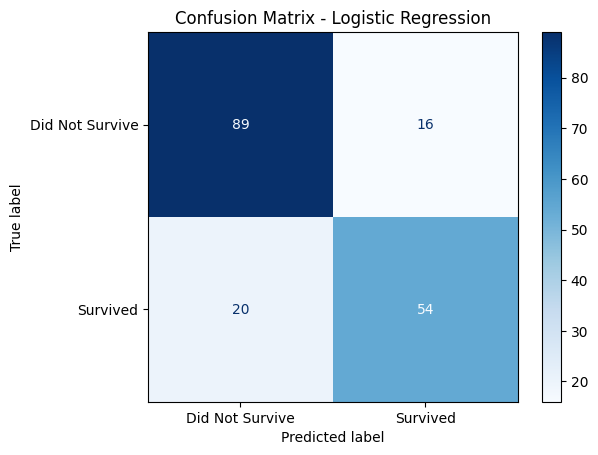

In [81]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=['Did Not Survive', 'Survived'],
    cmap='Blues'
)

plt.title('Confusion Matrix - Logistic Regression')
plt.show()

##### Interpretation

The logistic regression model achieved an accuracy of 79.9%, correctly classifying 143 out of 179 passengers in the test set. The confusion matrix shows that the model correctly predicted 89 passengers who did not survive and 54 passengers who survived, while misclassifying 16 passengers as survivors when they did not survive and 20 passengers as non-survivors when they actually survived.

In [78]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



##### Interpretation
The classification report indicates a precision of 77%, meaning that 77% of passengers predicted to survive actually survived. The model achieved a recall of 73%, indicating that it correctly identified 73% of all actual survivors. The F1-score of 75% reflects a good balance between precision and recall. Overall, these results suggest that the logistic regression model performs well in predicting passenger survival on the Titanic.

### Logistic Regressions(With feature engineering)

In [88]:
X_train_v2 = X_train.copy()
X_test_v2 = X_test.copy()
X_train_v2['sex_isalone'] = X_train_v2['sex_encoded'] * X_train_v2['isalone']
X_test_v2['sex_isalone'] = X_test_v2['sex_encoded'] * X_test_v2['isalone']

model_v2 = LogisticRegression(max_iter=1000, class_weight ='balanced')
model_v2.fit(X_train_v2, y_train)
y_pred_v2 = model_v2.predict(X_test_v2)
print(classification_report(y_test, y_pred_v2))

              precision    recall  f1-score   support

           0       0.88      0.79      0.83       105
           1       0.74      0.85      0.79        74

    accuracy                           0.82       179
   macro avg       0.81      0.82      0.81       179
weighted avg       0.82      0.82      0.82       179



##### Interpretation

Adding the Sex-IsAlone interaction term and using class_weight='balanced' improved the logistic regression model's ability to correctly identify survivors, raising recall for the survived class from 73% to 85%, while also slightly improving overall accuracy (79.9% → 82.1%). This came with a small tradeoff in precision and a slight drop in recall for the "died" class, which is expected when balancing performance across an imbalanced dataset

### Random Forest

In [90]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train_v2, y_train)
y_pred_rf = rf_model.predict(X_test_v2)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Confusion Matrix:
 [[89 16]
 [16 58]]


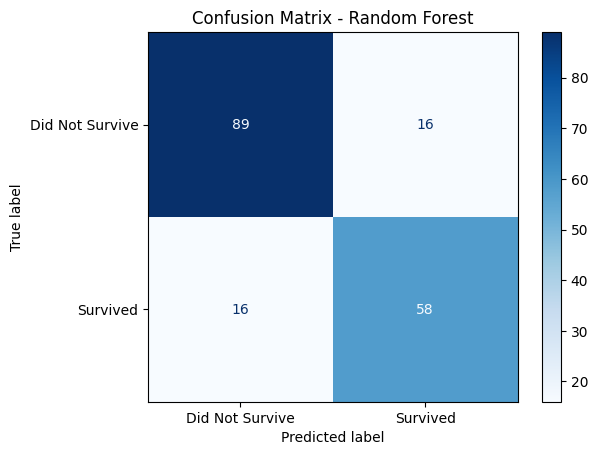

In [93]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['Did Not Survive', 'Survived'],
    cmap='Blues'
)

plt.title('Confusion Matrix - Random Forest')
plt.show()

In [91]:
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.85      0.85      0.85       105
           1       0.78      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179



##### Interpretation

The Random Forest model correctly classified 82.1% of passengers in the test set (147 out of 179). Unlike the earlier logistic regression models, this model performs evenly across both classes, precision and recall are identical (0.85/0.85) for passengers who died and identical (0.78/0.78) for passengers who survived. This balance is also visible in the confusion matrix: the number of false positives (16,predicted survived but died) exactly equals the number of false negatives (16, predicted died but survived), meaning the model does not systematically favor one type of error over the other.

Compared to the tuned logistic regression (v2), Random Forest achieves the same overall accuracy (82.1%) but distributes its performance more evenly rather than prioritizing survivor recall specifically. This makes Random Forest a more balanced general-purpose classifier, while logistic regression v2 remains the better choice if the specific goal is to minimize missed survivors (false negatives) even at some cost to overall balance.


In [94]:
import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=X_train_v2.columns).sort_values(ascending=False)
print(importances)

fare                0.305077
age                 0.269412
sex_encoded         0.209565
pclass              0.092289
sex_isalone         0.063565
embarked_encoded    0.033287
isalone             0.026804
dtype: float64


##### Interpretation
Random Forest feature importances rank Fare (0.305) and Age (0.269) as the top two predictors, followed by Sex (0.210) and Pclass (0.092). Notably, Age ranks highly here despite the earlier Mann-Whitney test showing no significant overall difference in Age distribution between survivors and non-survivors (p=0.27) — this suggests Age is useful for the model in a more localized way (e.g., distinguishing children from adults) rather than shifting the full distribution, which the Mann-Whitney test would not detect. The Sex-IsAlone interaction term (0.064) also shows measurable importance, consistent with its statistical significance found earlier via logistic regression (p=0.002). Embarked ranks lowest (0.033), supporting the earlier hypothesis that it primarily acts as a proxy for Pclass/Fare rather than an independent predictor.

## Model Comparison Summary

| Metric | Logistic Regression (Original) | Logistic Regression v2 (Interaction + Balanced) | Random Forest |
|---|---|---|---|
| Accuracy | 0.799 | 0.821 | 0.821 |
| Precision (Died) | 0.82 | 0.88 | 0.85 |
| Recall (Died) | 0.85 | 0.79 | 0.85 |
| F1 (Died) | 0.83 | 0.83 | 0.85 |
| Precision (Survived) | 0.77 | 0.74 | 0.78 |
| Recall (Survived) | 0.73 | 0.85 | 0.78 |
| F1 (Survived) | 0.75 | 0.79 | 0.78 |

##### Conclusion

All three models performed reasonably well, with accuracy ranging from 79.9% to 82.1%. 
The baseline logistic regression provided a solid starting point but underperformed 
specifically at identifying survivors, correctly recalling only 73% of them.

Adding the Sex-IsAlone interaction term (validated as statistically significant via 
logistic regression, p=0.002) and applying class balancing produced Logistic Regression 
v2, which matched the highest accuracy (82.1%) while substantially improving survivor 
recall to 85%, the best of all three models on this specific metric. This came at a 
modest cost to precision and to recall on the "died" class, reflecting a deliberate 
trade-off favoring the detection of survivors.

Random Forest also achieved 82.1% accuracy but distributed its performance more evenly 
across both classes (0.78 precision and recall for survivors, 0.85 for died), making it 
the more balanced general-purpose model. Its feature importances confirmed Fare, Age, 
and Sex as the strongest predictors, consistent with earlier EDA and hypothesis testing, 
and validated the Sex-IsAlone interaction as a meaningful (if smaller) contributor.

**Final recommendation:** If the priority is a well-rounded model with no strong bias 
toward either outcome, Random Forest is the better choice. If the priority is minimizing 
missed survivors specifically (i.e., false negatives matter more than false positives), 
Logistic Regression v2 is the stronger option, given its notably higher survivor recall 
at an equivalent overall accuracy.

##### Limitations
Computation bias: Missing ages were filled with the median, which creates an artificial spike at age 28 that isn't real clustering — this can distort age-based comparisons.

Dropped the cabin column entirely due to missingness, losing potentially useful info (e.g., deck location relative to lifeboats).
Correlation vs. causation, beyond just the port example: the same confounding logic likely applies elsewhere (e.g., fare and class are highly collinear, so "fare predicts survival" is partly just "class predicts survival" restated).

Small subgroup sizes: Queenstown (n=77) and larger family sizes have small counts, so survival rates for those groups are less statistically stable than they look.

Multiple hypothesis tests without correction: Five significance tests were run without adjusting for multiple comparisons, which raises the chance of at least one false positive.

Class imbalance: ~62% died vs. 38% survived, so raw accuracy can be a bit misleading; precision/recall by class matters more (you already addressed this with class_weight='balanced', worth noting as a limitation you handled).

Single train/test split: No cross-validation, so the reported accuracy/precision/recall are point estimates with real variance — different splits could shift results a few points.
